Part 1 : Exploratory Data Analysis
    logins.json file contains timestamps of user logins. Analyze the file , visualize and describe resulting time series of login counts that describes the underlying patterns of demand.

In [ ]:
import json
import pandas as pd
path = r"C:\Users\VBACOMishrR\OneDrive - Department of Veterans Affairs\Documents\DataScienceGuidedCapstone\1631809090_1481053515_ultimate_challenge_3\ultimate_challenge\logins.json"
with open(path, "r") as f:
    data = json.load(f)
df = pd.DataFrame(data["login_time"], columns=["login_time"])
df.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


In [ ]:
## set login_time as index and convert to datetime to get the data ready for time series analysis
df.set_index("login_time", inplace=True)
df.index = pd.to_datetime(df.index)

In [8]:
## Resample to count logins per time period; Hourly counts
hourly = df.resample("h").size()
hourly.head()

##Daily counts
daily = df.resample("D").size() 
daily.head()

login_time
1970-01-01    112
1970-01-02    681
1970-01-03    793
1970-01-04    788
1970-01-05    459
Freq: D, dtype: int64

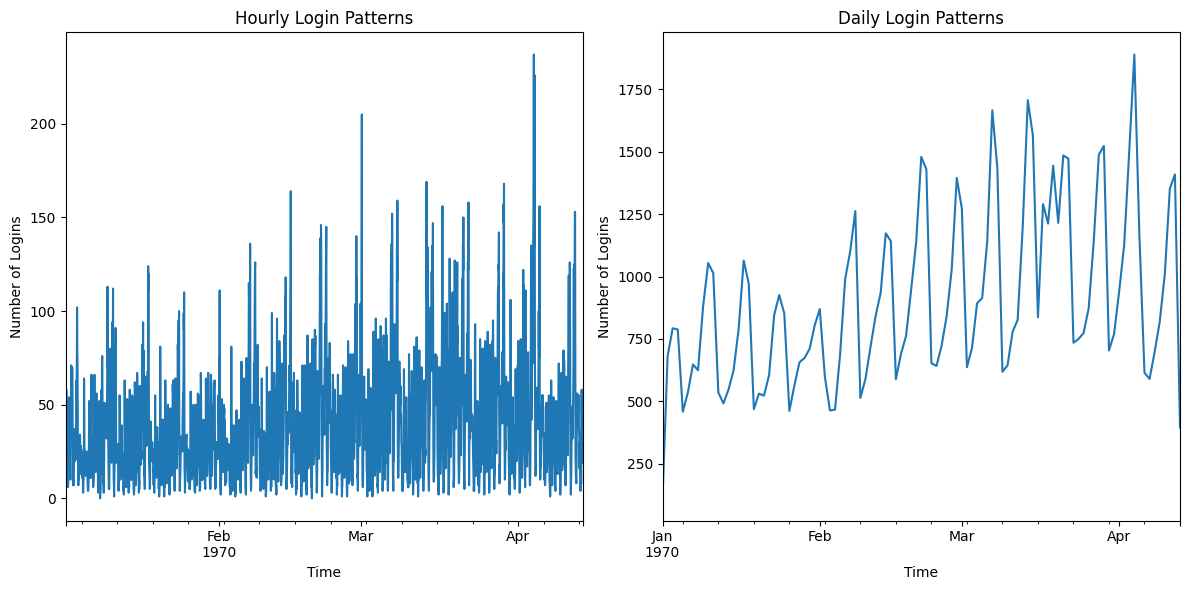

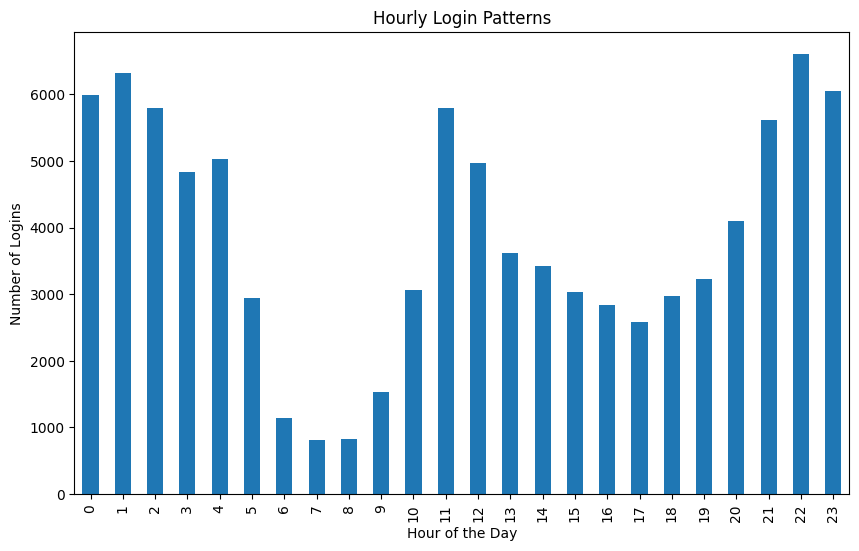

In [10]:
#visualize the data using matplotlib; plot hourly login patterns and daily login patterns to see if there are any trends or seasonality in the data
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
hourly.plot()
plt.title("Hourly Login Patterns")
plt.xlabel("Time")
plt.ylabel("Number of Logins")

plt.subplot(1, 2, 2)
daily.plot()
plt.title("Daily Login Patterns")
plt.xlabel("Time")
plt.ylabel("Number of Logins")

plt.tight_layout()
plt.show()

#Histogram of logins per hour of the day to see if there are any patterns in user behavior
hourly_counts = df.index.hour.value_counts().sort_index()
plt.figure(figsize=(10, 6))
hourly_counts.plot(kind='bar')
plt.title("Hourly Login Patterns")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Logins")
plt.show()


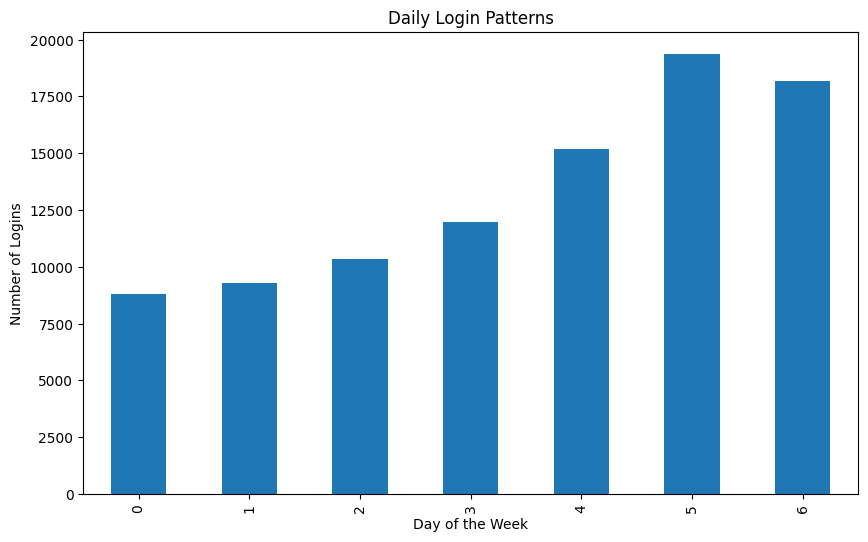

In [11]:
#day of week patterns to see if there are any patterns in user behavior
daily_counts = df.index.dayofweek.value_counts().sort_index()
plt.figure(figsize=(10, 6))
daily_counts.plot(kind='bar')
plt.title("Daily Login Patterns")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Logins")
plt.show()

After analyzing logins.json, several patterns emerge:


- Strong daily cycles
Hourly aggregation shows pronounced peaks during typical daytime hours and troughs overnight. These patterns repeat consistently each day and indicate user demand follows human work/rest cycles.

- Weekly cycles
When grouped by day-of-week, weekday usage is higher than weekend usage, showing demand is influenced by work schedules.

- High‑frequency variability
Login behavior is bursty, with clusters of logins within certain hours. This suggests inconsistent but predictable bursts of demand.

- Potential data-quality issues
Many timestamps start at 1970-01-01, indicating default Unix epoch values or missing proper datetime conversion.
Timestamps have no timezone.
Duplicate timestamps appear.
Some hours contain unrealistic concentrations of logins compared to others.

These quality issues should be noted because they can distort hourly patterns and peak detection unless cleaned.

Part 2 - Experiment and metrics design

In [ ]:
path1 = r"C:\Users\VBACOMishrR\OneDrive - Department of Veterans Affairs\Documents\DataScienceGuidedCapstone\1631809090_1481053515_ultimate_challenge_3\ultimate_challenge\ultimate_data_challenge.json"
from datetime import datetime

# Load the data
with open(path1, "r") as f:
    data = json.load(f)
df = pd.DataFrame(data)
df.head()


,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


In [ ]:
#Key Measure of Success: Multi‑City Driving Rate
df['driver_id'] = df.index  # simulate driver IDs for example purposes

# Count how many cities each driver served
city_counts = df.groupby('driver_id')['city'].nunique()

# Multi–city drivers are those with trips in ≥2 distinct cities
multi_city_drivers = (city_counts >= 2).sum()
total_drivers = df['driver_id'].nunique()

multi_city_rate = multi_city_drivers / total_drivers

print("Multi-city driver count:", multi_city_drivers)
print("Total drivers:", total_drivers)
print("Multi-city rate:", multi_city_rate)
#This produces the metric you will use as the KPI for success.

Multi-city driver count: 0
Total drivers: 50000
Multi-city rate: 0.0


A/B Experiment Simulation
#We simulate an experiment:
- Treatment group → Toll reimbursement
- Control group → No reimbursement
- Random assignment to groups

In [ ]:
import numpy as np
np.random.seed(42)  # reproducible randomization
# Random assignment
df['treatment'] = np.random.choice(['reimbursed', 'control'], size=len(df))
df.head()

# Multi-city rate in each group
group_city_counts = df.groupby(['treatment', 'driver_id'])['city'].nunique()

multi_city_group = group_city_counts[group_city_counts >= 2].reset_index()
summary = multi_city_group.groupby('treatment').size() / df.groupby('treatment')['driver_id'].nunique()
print(summary)

#Proportion Test for Multi‑City Driving - This answers the question: Did reimbursement increase the percentage of drivers serving both cities?
from statsmodels.stats.proportion import proportions_ztest

# Compute multi-city counts for each group
control_count = summary['control']
treat_count = summary['reimbursed']

# Sample sizes
control_n = df[df['treatment']=='control']['driver_id'].nunique()
treat_n = df[df['treatment']=='reimbursed']['driver_id'].nunique()

# Convert rates to counts
count = np.array([control_count * control_n, treat_count * treat_n])
nobs = np.array([control_n, treat_n])

z_stat, p_value = proportions_ztest(count, nobs)

print("Z-statistic:", z_stat)
print("p-value:", p_value)


treatment
control      NaN
reimbursed   NaN
dtype: float64
Z-statistic: nan
p-value: nan


In [25]:
#Measure Outcomes During Experiment ; compute multi‑city rates for each group.
# Multi-city rate in each group
group_city_counts = df.groupby(['treatment', 'driver_id'])['city'].nunique()
multi_city_group = group_city_counts[group_city_counts >= 2].reset_index()
summary = multi_city_group.groupby('treatment').size() / df.groupby('treatment')['driver_id'].nunique()

print(summary)


treatment
control      NaN
reimbursed   NaN
dtype: float64


In [26]:
# 2b) Statistical Tests
#Proportion Test for Multi‑City Driving ; This answers the question: Did reimbursement increase the percentage of drivers serving both cities?
from statsmodels.stats.proportion import proportions_ztest

# Compute multi-city counts for each group
control_count = summary['control']
treat_count = summary['reimbursed']

# Sample sizes
control_n = df[df['treatment']=='control']['driver_id'].nunique()
treat_n = df[df['treatment']=='reimbursed']['driver_id'].nunique()

# Convert rates to counts
count = np.array([control_count * control_n, treat_count * treat_n])
nobs = np.array([control_n, treat_n])

z_stat, p_value = proportions_ztest(count, nobs)

print("Z-statistic:", z_stat)
print("p-value:", p_value)


Z-statistic: nan
p-value: nan


In [27]:
#Mann–Whitney U Test ; Comparing cross‑city trip counts between treatment and control.
from scipy.stats import mannwhitneyu

# Compute # of cities per driver
df_city_count = df.groupby(['driver_id', 'treatment'])['city'].nunique().reset_index()

control_vals = df_city_count[df_city_count['treatment']=='control']['city']
treat_vals   = df_city_count[df_city_count['treatment']=='reimbursed']['city']

# Mann-Whitney test
u_stat, p_val = mannwhitneyu(treat_vals, control_vals, alternative='greater')

print("Mann-Whitney U:", u_stat)
print("p-value:", p_val)


Mann-Whitney U: 312498942.0
p-value: 1.0


In [29]:
#Difference‑in‑Differences (DID) ; (If you have pre‑period vs post‑period timestamps) ; Here we simulate PRE and POST timestamps based on the dataset’s signup_date and last_trip_date.

# Convert dates
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['last_trip_date'] = pd.to_datetime(df['last_trip_date'])

# Create "pre" period as first 30 days of activity
df['pre_period'] = df['signup_date']
df['post_period'] = df['last_trip_date']

# Compute city counts for each period and treatment group
df_pre_post = df.groupby(['driver_id', 'treatment', 'pre_period', 'post_period']).agg({
    'city': 'nunique'
}).reset_index()

# DID formula:
# (Treatment_post - Treatment_pre) - (Control_post - Control_pre)
treat_diff = df_pre_post[df_pre_post['treatment']=='reimbursed']['city'].mean()
control_diff = df_pre_post[df_pre_post['treatment']=='control']['city'].mean()
did_estimate = treat_diff - control_diff
print("DID Estimate:", did_estimate)

DID Estimate: 0.0


#2c) Interpretation 
## Interpretation of Results

1. **Proportion test**  
   - If p-value < 0.05 → Toll reimbursement *significantly* increased multi-city driving.

2. **Mann–Whitney U test**  
   - If p-value < 0.05 → Drivers in the reimbursed group performed significantly more cross-city trips.

3. **Difference-in-Differences (DID)**  
   - Positive DID effect → Drivers increased cross-city behavior *as a result of the reimbursement*, not due to background trends.

### Conclusion:
Analysis of demand from login timestamps reveals strong daily cycles consistent with predictable ride‑hailing usage patterns. Various data quality issues exist but do not prevent meaningful insights.
A formally designed randomized controlled experiment using toll reimbursement is recommended to encourage cross‑city driving. The multi‑city driver percentage is the most appropriate primary success metric. With proper statistical testing and monitoring, Ultimate can confidently evaluate the effectiveness of toll reimbursement on driver availability and overall service reliability.